# wis quickstart: querying observatory positions

This notebook demonstrates the basic wis workflow using the TESS satellite (MPC code C57).
We will:

- load the TESS kernel alongside the DE440 ground ephemeris
- query TESS's position over one year
- compare two ways of expressing those positions: in the barycentric (SSB) frame and
  in a frame centered on Earth

Note that this notebook also relies on a handful of other standard astronomy python packages including `astropy`,`numpy`, and `matplotlib`. If you have not already, you can install these with `pip install astropy numpy matplotlib`.

In [1]:
%matplotlib inline
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from wis.kernels import DE440, TESS

from wis import Wis

## Setting up time grids and querying positions

We build two time arrays: a coarse annual grid for the solar-system-scale view and a finer two-month grid for the orbital-scale view.  All position queries happen inside a single `with Wis(...)` context, which downloads any missing kernels on entry and clears them on exit.

If you don't have the required kernels downloaded, the first time you run this notebook it will take a few minutes to download and cache them. After that, it should run much faster.

In [2]:
# Annual grid: 2022, daily cadence
times_yr = Time("2022-01-01") + np.arange(366) * u.day

# Fine grid: 60 days at 3-hour cadence (~4.4 TESS orbits)
times_fine = Time("2022-01-01") + np.arange(480) * (3 * u.hour)

with Wis(kernels=[DE440, TESS]) as w:
    # Barycentric positions (SSB = origin) [AU]
    tess_bary = w.get_obs_bary_equ_AU("C57", times_yr)  # shape (366, 3)
    earth_bary = w.get_obs_bary_equ_AU("500", times_yr)  # geocenter

    # Heliocentric positions on the fine grid
    tess_helio, _ = w.get_obs_helio_equ_AU("C57", times_fine)
    earth_helio, _ = w.get_obs_helio_equ_AU("500", times_fine)

# TESS geocentric position [AU]: TESS minus Earth, both heliocentric
tess_geo = tess_helio - earth_helio

## Barycentric (SSB) frame

In the barycentric frame the origin is the solar-system barycenter.  At the scale of an
astronomical unit, TESS and Earth trace nearly the same annual path — TESS is only
~400,000 km from Earth, which is tiny compared to their ~1 AU distance from the Sun.

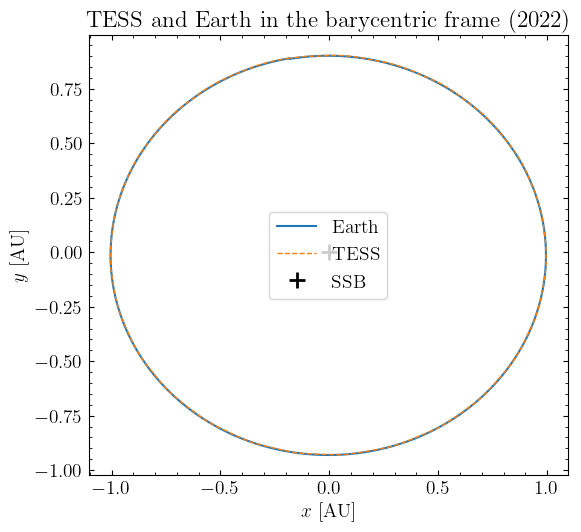

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(earth_bary[:, 0], earth_bary[:, 1], lw=1.5, label="Earth")
ax.plot(tess_bary[:, 0], tess_bary[:, 1], lw=1, ls="--", label="TESS")
ax.plot(0, 0, "k+", ms=12, mew=2, label="SSB", zorder=5)

ax.set_xlabel(r"$x$ [AU]")
ax.set_ylabel(r"$y$ [AU]")
ax.set_aspect("equal")
ax.legend()
ax.set_title("TESS and Earth in the barycentric frame (2022)")
plt.tight_layout()
plt.show()

## Geocentric frame

Centering on Earth reveals TESS's actual orbit.  We compute TESS's geocentric position by
subtracting Earth's heliocentric position.  The scatter color encodes elapsed time,
showing the direction of orbital motion.

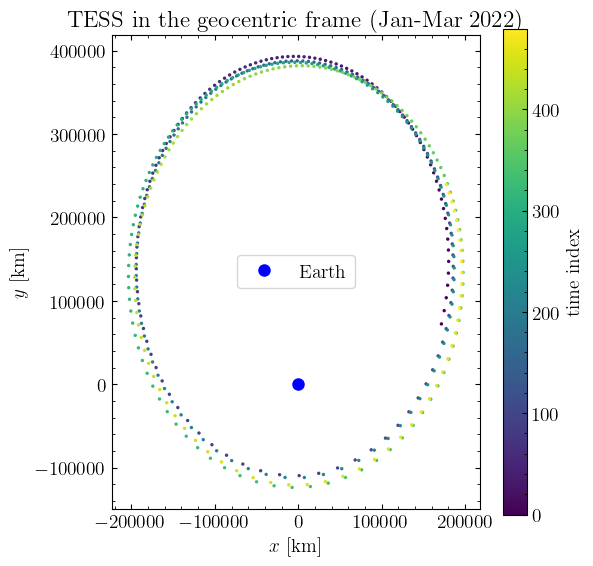

In [4]:
# Convert AU to km for a more intuitive scale at this distance
tess_geo_km = tess_geo * u.AU.to(u.km)

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    tess_geo_km[:, 0],
    tess_geo_km[:, 1],
    c=np.arange(len(times_fine)),
    cmap="viridis",
    s=6,
    lw=0,
)
ax.plot(0, 0, "bo", ms=8, label="Earth", zorder=5)
plt.colorbar(sc, ax=ax, label="time index")

ax.set_xlabel(r"$x$ [km]")
ax.set_ylabel(r"$y$ [km]")
ax.set_aspect("equal")
ax.legend()
ax.set_title("TESS in the geocentric frame (Jan-Mar 2022)")
plt.tight_layout()
plt.show()

## Summary

The `Wis` context manager is the main entry point:

| Method | Returns |
|--------|---------|
| `get_obs_helio_equ_AU(obscode, times)` | positions and light-travel times, heliocentric [AU, days] |
| `get_obs_bary_equ_AU(obscode, times)` | positions, barycentric (SSB = origin) [AU] |
| `get_bary_wrt_helio(times)` | SSB position, velocity, and light-travel time relative to the Sun |

Other built-in kernels available from `wis.kernels`: `DE440`, `KEPLER`, `GAIA`, `HST`, `JWST`.